Based on: https://github.com/icepack/icepack2/commits/75b5b1413af3ad7d584424f9b4e64ad0bc57988f/notebooks/mismipp-dual-1d.ipynb

In [1]:
from pathlib import Path
import logging
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from tqdm.notebook import tqdm, trange
import firedrake as fd
from firedrake import (
    eq,
    conditional,
    min_value,
    max_value,
    exp,
    sqrt,
    inner,
    sym,
    tr,
    grad,
    Constant,
    dx,
    ds,
    dS,
    avg,
    jump,
)
import irksome
from irksome import Dt, lag
from icepack.constants import (
    weertman_sliding_law,
    glen_flow_law,
    gravity as g,
    ice_density as ρ_I,
    water_density as ρ_W,
)
import ufl
from ufl.tensors import as_scalar

import scipy as sp

import timeit

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
print(weertman_sliding_law) # sometimes called m
print(glen_flow_law) # sometimes called n

3.0
3.0


## Definitions of the laws

In [3]:
# q is functional and we extract the coefficients, z, and then create a test function, w, 
# on the function space that z was defined on and then replace z by w
def get_test_function(q):
    z, = ufl.algorithms.extract_coefficients(q) # the comma unpacks a list with just one element so z is the item in the list not the list
    w = fd.TestFunction(z.function_space()) 
    return fd.replace(q, {z: w}) # variable substitution (the new variables are w)

In [4]:
# n = 3 #Constant(glen_flow_law)
# m = 3 #Constant(weertman_sliding_law)

In the following we define the variational form of the friction law $\langle K |\tau|^2 \tau + f u, \sigma \rangle$.
Next we do the same for the flow law $$\frac{1}{2} h\cdot A\cdot \left(|M|^2 -\frac{\text{tr}(M)^2}{d+1}\right)\cdot \left(\langle M, N\rangle -\frac{\text{tr}(M)\text{tr}(N)}{d+1} \right) - \langle \varepsilon , N \rangle,$$
where $\varepsilon = \frac{\nabla u +\nabla u ^T}{2}$ is the strain rate. <br>
In the first case $\sigma$ is the test function whereas in the second case $N$ is the test function.


In [5]:
# Ada: We assume here surface be part of fields
def friction_law(**kwargs):
    τ, u, h, s = map(kwargs.get, ("basal_stress", "velocity", "thickness", "surface"))
    parameters = ("sliding_coefficient", "sliding_exponent")
    K, m = map(kwargs.get, parameters)

    # lag makes sure the expression is only evaluated at the beginning of the timestep and then remains constant
    p_W = lag(ρ_W * g * max_value(0, -(s - h))) # this is the pressure of the water and it changes with the values of s (surface)
    
    p_I = ρ_I * g * h # this is the pressure of the ice 
    r = Constant(0.99)
    ϕ = lag(conditional(p_W > r * p_I, 0, 1)) # if p_W > r * p_I is true then phi equals 0 and otherwise it equals 1 (kronecker delta)

    σ = get_test_function(τ)
    τ_2 = inner(τ, τ)

    # m is the sliding law exponent
    if m == 1:
        τ_m = Constant(1.0)
    elif m == 3:
        τ_m = τ_2
    elif m == 5:
        τ_m = τ_2 ** 2
    else:
        raise ValueError("Sliding law exponent must be in [1, 3, 5]!")

    f = ϕ if m == 1 else ϕ ** m

    return inner(K * τ_m * τ + f * u, σ) * dx

In [6]:
def flow_law(dimension, **kwargs):
    variables = ("velocity", "membrane_stress", "thickness")
    u, M, h = map(kwargs.get, variables)
    parameters = ("flow_law_coefficient", "flow_law_exponent")
    A, n = map(kwargs.get, parameters)

    N = get_test_function(M)
    d = dimension
    M_2 = (inner(M, M) - tr(M)**2 / (d + 1)) / 2

    if n == 1:
        M_n = Constant(1.0)
    elif n == 3:
        M_n = M_2
    elif n == 5:
        M_n = M_2 ** 2
    else:
        raise ValueError("Flow law exponent must be in [1, 3, 5]!")

    ε = sym(grad(u)) # symmetric part of the gradient of u so 1/2(grad(u)+grad(u)^T)
    return h * (A * M_n * (inner(M, N) - tr(M) * tr(N) / (d + 1)) - inner(ε, N)) * dx

For momentum balance we get 
$\int -h \langle M, \varepsilon \rangle +\langle \tau-\rho_I g h \nabla s, v\rangle dx+ \int\rho_I \text{avg}(h) \langle \text{jump}(s)\cdot \nu, \text{avg}(v)\rangle dS $, where $\varepsilon = \frac{\nabla v +\nabla v^T}{2}$. <br>
The function $\text{avg}(v)$ means that, when considering the facet between two cells and using the discontinuous Galerkin method, we take 
$\frac{v(+)+v(-)}{2}$. Similarly, $\text{jump}(s)$ gives us the discontinuity of s over different facets.

In [7]:
def momentum_balance(mesh, **kwargs):
    variables = (
        "velocity", "membrane_stress", "basal_stress", "thickness", "surface"
    )
    u, M, τ, h, s = map(kwargs.get, variables)
    v = get_test_function(u)

    ε = sym(grad(v))
    cell_balance = (-h * inner(M, ε) + inner(τ - ρ_I * g * h * grad(s), v)) * dx

    ν = fd.FacetNormal(mesh)
    facet_balance = ρ_I * g * avg(h) * inner(jump(s, ν), avg(v)) * dS #fd.avg() gives us the average at a discontinuous spot (so a method for 'DG') 

    return cell_balance + facet_balance

For the terminus we have $\int\frac{\rho_I g h^2-\rho g \min(s-h, 0)}{2}\langle v, \nu\rangle ds$ on the part of the boundary given by 'terminus_ids'.

In [8]:
def terminus(mesh, **kwargs):
    variables = ("velocity", "thickness", "surface", "terminus_ids")
    u, h, s, terminus_ids = map(kwargs.get, variables)
    v = get_test_function(u)

    d = fd.min_value(s - h, 0)
    τ_I = ρ_I * g * h**2 / 2
    τ_W = ρ_W * g * d**2 / 2

    ν = fd.FacetNormal(mesh)
    return (τ_I - τ_W) * inner(v, ν) * ds(terminus_ids)

In [9]:
def smooth_max(a, b, ϵ):
    return (a + b + ((a - b)**2 + ϵ**2) ** 0.5) / 2

The expression $\int (\text{D}t(h) \eta - \langle h u, \nabla \eta\rangle - a\eta) \text{d}x + \int \text{jump}(h \max(0, \langle u,\nu\rangle))\text{jump}(\eta)\text{d}S 
+\int h \max(0, \langle u,\nu\rangle)\eta \text{d}s + \int h_\text{in}\min(0,\langle u, \nu\rangle)\eta\text{d}s$ gives us the mass balance.

In [10]:
def mass_balance(mesh, **kwargs):
    variables = ("thickness", "velocity", "accumulation", "thickness_in")
    h, u, a, h_in = map(kwargs.get, variables)
    η = get_test_function(h)

    ν = fd.FacetNormal(mesh)
    F_cells = (Dt(h) * η - inner(h * u, grad(η)) - a * η) * dx
    f = h * max_value(0, inner(u, ν))
    F_facets = jump(f) * jump(η) * dS
    F_outflow = f * η * ds
    F_inflow = h_in * min_value(0, inner(u, ν)) * η * ds
    return F_cells + F_facets + F_outflow + F_inflow

## Initialization and setting the values

In [11]:
DEFAULT_LX = 610e3 # overall length of the mesh
DEFAULT_NX = 450 # number of intervals

In [12]:
class Spaces:
    """
    Function spaces that define the bed geometry, velocity/height profiles and
    stress.

    All properties are immutable. Mutable variables from values must be
    derived with deepcopy.
    """

    DEFAULT_DEGREE = 1

    def __init__(self, mesh, *, degree = DEFAULT_DEGREE):
        """
        Initialize function spaces from a given mesh
        """
        self.mesh = mesh

        # basic properties of the function spaces
        self.degree = degree
        self.x = fd.SpatialCoordinate(self.mesh)[0]


        # function spaces
        thickness_element = fd.FiniteElement("DG", "interval", 0)
        bed_element = fd.FiniteElement("CG", "interval", 1)
        velocity_element = fd.FiniteElement("CG", "interval", self.degree)
        stress_element = fd.FiniteElement("DG", "interval", self.degree - 1)

        self.Q = fd.FunctionSpace(self.mesh, thickness_element)
        self.S = fd.FunctionSpace(self.mesh, bed_element)
        self.V = fd.VectorFunctionSpace(self.mesh, velocity_element)
        self.Σ = fd.TensorFunctionSpace(self.mesh, stress_element, symmetry=True)

        # misc properties
        self.nx = mesh.num_cells()
        self.lx = np.max(mesh.coordinates.dat.data_ro)
        self.Lx = Constant(self.lx)

        # Describe the bed over S (it does not change)
        # Note: does not belong here since it is not a space but an object
        # in `S`
        # We utilize the mismip+ bed
        self.b = fd.Function(self.S).interpolate(self.mismip_bed(self.x))

    def get_new_w(self):
        # cartesian product, velocity * stress * velocity * thickness
        W = self.V * self.Σ * self.V * self.Q
        return fd.Function(W)

    @staticmethod
    def mismip_bed(x):
        # internal magic constant
        B_0 = Constant(-150)
        B_2 = Constant(-728.8)
        B_4 = Constant(343.91)
        B_6 = Constant(-50.57)
        x_c = Constant(300e3)
        X = x / x_c
        B_x = B_0 + B_2 * X**2 + B_4 * X**4 + B_6 * X**6
        # z_deep = Constant(-720)    
        return B_x

    # Alternativel bed currently unused
    @staticmethod
    def _linear_bed(Lx, x):
        b_in, b_out = 200, -400
        b_x = (b_in - (b_in - b_out) * x / Lx)
        return b_x

    @classmethod
    def create(
        cls,
        *,
        lx = DEFAULT_LX,
        nx = DEFAULT_NX,
        degree = DEFAULT_DEGREE,
        name = fd.DEFAULT_MESH_NAME
    ) -> "Spaces":
        """
        Create new mesh and function spaces
        """
        mesh = fd.IntervalMesh(nx, lx, name=name)
        return cls(mesh, degree = degree)

    def store_to_handle(self, handle):
        """
        Store spaces to a checkpoint file handle
        """
        handle.save_mesh(self.mesh)

    @classmethod
    def restore_from_handle(cls, handle, *, degree = DEFAULT_DEGREE, name = fd.DEFAULT_MESH_NAME) -> Spaces:
        """
        Restore from a checkpoint file handle
        """
        try:
            m = handle.load_mesh(name)
        except Exception as e:
            logging.error(f"failed to restore spaces from checkpoint handle: {e}")
            raise
        return cls(m, degree = degree)

    @classmethod
    def restore_from_file(cls, path, *, degree = DEFAULT_DEGREE, name = fd.DEFAULT_MESH_NAME) -> Spaces:
        try:
            with fd.CheckpointFile(path, "r") as chk:
                return cls.restore_from_handle(chk, degree=degree, name=name)
        except Exception as e:
            logging.error(f'Unexpected failure while restoring spaces from checkpoint file: {e}')
            raise


# Note on State:

* mesh: immutable environment
* spaces: immutable product of function spaces
* state: mutable fd variables corresponds to components of spaces
* derived state: fd formulas over the stateful variables

Spaces:
* `V`: velocity_element (used for glacier velocity and basal stress)
* `Σ`: used for membrane stress
* `Q`: used for thickness
* `S`: used for bed (not used in solver because the bed is fixed)

Components of the State are:
* `z` contains `u` (over `V`), `M` (over `Σ`), `τ` (over `V`)
* `h` over `Q`, which is independent of `z`.

Derived State:
* `s` (surface) over `h` 


TODO: define simulation state (fields) and its properties.


In the simulation three different definitions of `s` are used.

Similarly, `z_b` is derived from `h` and `s`.

In [13]:
# initial_*: creates immutable initial value
# init_*: initializes mutable value

# h0
def initial_thickness(spaces):
    h_in = Constant(200.0)
    δh = Constant(100.0)
    h_expr = h_in - δh * spaces.x / spaces.Lx
    return fd.Function(spaces.Q).interpolate(h_expr) # thickness

# h
def init_thickness(spaces):
    return initial_thickness(spaces).copy(deepcopy=True)

def initial_velocity(spaces):
    δu = fd.Constant(90.0)
    expr = fd.as_vector([δu * spaces.x / spaces.Lx])  # 1-component vector
    return fd.Function(spaces.V).interpolate(expr)

def init_velocicty(spaces):
    return initial_velocity(spaces).copy(deepcopy=True)




In [14]:
def f():
    a = 1
    b = 2
    c = 3
    return a + b + c

d = f()

In [24]:
# Surface Formulas
#
# The only variable that the surface depends on is h, which is solved only in
# the second simulation phase.

# Smooth initial surface
#
# In orignal model only used for plotting of initial surface (never solved)
#
def smooth_initial_surface(spaces):
    ϵ = Constant(0.1)
    # the second term governs flotation and the eps ensures that the transition from gounded to floating is smooth
    # Ada: do we need a deepcopy of h0 here? Initial surface is immutable
    h0 = initial_thickness(spaces)
    s_expr = smooth_max(spaces.b + h0, (1 - ρ_I / ρ_W) * h0, ϵ)
    return fd.Function(spaces.Q).interpolate(s_expr)

def smooth_init_surface(space):
    return smooth_initial_surface(spaces).copy(deepcopy=True)

# Surface without lag
#
# used in first simulation phase with constant/initial `h`.
#
#
def initial_surface(spaces):
    h0 = initial_thickness(spaces)
    return fd.Function(spaces.Q).interpolate(max_value(spaces.b + h0, (1 - ρ_I / ρ_W) * h0))

# Surface with lag
#
# Used in second simulation phase based on dynamic h
#
def lag_initial_surface(spaces, h):
    return lag(max_value(spaces.b + h, (1 - ρ_I / ρ_W) * h))


In [16]:
STEADY_STATE_CACHE_PATH = "steady-state.h5"
STEADY_STATE_NAME = f"w"

def store_steady_state(mesh, w):
    with fd.CheckpointFile(STEADY_STATE_CACHE_PATH, "w") as chk:
        chk.save_mesh(mesh)
        chk.save_function(w, name=STEADY_STATE_NAME)

def load_steady_state(mesh):
    try:
        with fd.CheckpointFile(STEADY_STATE_CACHE_PATH, "r") as chk:
            mesh = chk.load_mesh("mesh")
            w = chk.load_function(mesh, name=STEADY_STATE_NAME)
            return (mesh, w)
    except FileExistsError:
        return None
    except Exception as e:
        logging.warning(f'Unexpected failure while load cache file {STEADY_STATE_CACHE_PATH}: {e}')
        return None

def clear_cache():
    Path(STEADY_STATE_CACHE_PATH).unlink(missing_ok=True)


In [17]:
STEADY_STATE_CACHE_PATH = "steady-state.h5"
spaces = Spaces.restore_from_file(STEADY_STATE_CACHE_PATH, name = "mesh")

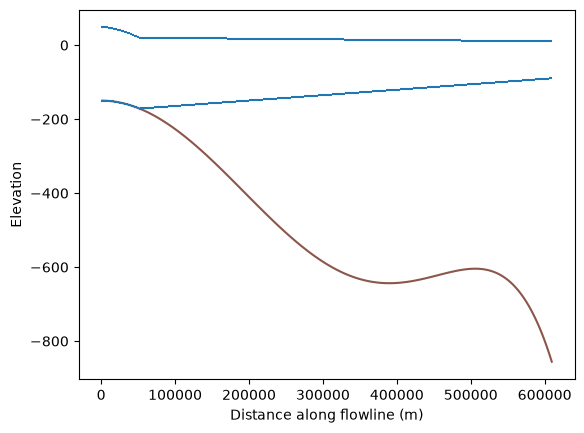

In [27]:
def plot_glacier(spaces):
    h0 = initial_thickness(spaces)
    s0 = initial_surface(spaces)
    
    # surface elevation minus the height of the glacier/ice shelf
    z_b = fd.Function(spaces.Q).interpolate(s0 - h0)

    fig, axes = plt.subplots()
    fd.plot(spaces.b, axes=axes, edgecolor="tab:brown") # bed
    fd.plot(s0, axes=axes, edgecolor="tab:blue") # initial surface of the glacier and ice shelf
    fd.plot(z_b, axes=axes, edgecolor="tab:blue") # initial base of the glacier and ice shelf
    axes.set_xlabel('Distance along flowline (m)')
    axes.set_ylabel('Elevation')
    plt.show()

plot_glacier(spaces)

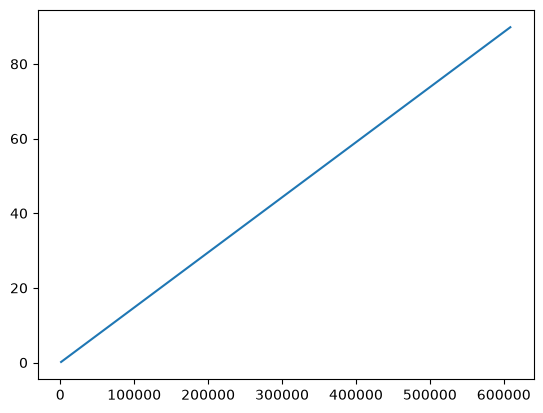

In [28]:
def plot_initial_velocity(spaces):
    u_0 = initial_velocity(spaces)
    _, axes = plt.subplots()
    fd.plot(fd.Function(spaces.S).interpolate(u_0[0]), axes=axes)
    plt.show()

plot_initial_velocity(spaces)

## Setting up and solving $F$

In [29]:
A = Constant(20)
K = Constant(1e6)

τ_c = Constant(0.01)
ε_c = Constant(A * τ_c ** glen_flow_law)
u_c = Constant(K * τ_c ** weertman_sliding_law)

In [30]:
print(f"Strain rate: {1000 * float(ε_c):0.3f} m / yr / km")
print(f"Speed:       {float(u_c):0.3f} m / yr")
print(f"at stress of {1000 * float(τ_c):0.3f} kPa")

Strain rate: 0.020 m / yr / km
Speed:       1.000 m / yr
at stress of 10.000 kPa


Initialization of function spaces and mass/momentum balance

In [45]:
from dataclasses import dataclass, asdict
from typing import Any

class F:
    @dataclass
    class Fields:
        velocity: Any
        thickness: Any
        surface: Any
        membrane_stress: Any
        basal_stress: Any

    @dataclass
    class Parameters:
        flow_law_coefficient: Any
        flow_law_exponent: Any
        sliding_coefficient: Any
        sliding_exponent: Any

    def __init__(self, S: Spaces, *, glen_flow_law = glen_flow_law, weertman_sliding_law = weertman_sliding_law):

        # immutable
        self.Z = S.V * S.Σ * S.V
        u_0 = initial_velocity(S)

        # mutable state
        self.z = fd.Function(self.Z)
        self.z.sub(0).assign(u_0)
        self.h = init_thickness(S)
        self.s = smooth_init_surface(S)

        inflow_ids = (1,) # the comma ensures that this is a tuple with a single element and not just an integer
        terminus_ids = (2,)

        self.s = max_value(S.b + self.h, (1 - ρ_I / ρ_W) * self.h)

        u, M, τ = fd.split(self.z)

        self.glen_flow_law = glen_flow_law
        self.weertman_sliding_law = weertman_sliding_law

        n = glen_flow_law
        m = weertman_sliding_law
        self.fields = F.Fields(u, self.h, self.s, M, τ)
        self.parameters_1 = F.Parameters(ε_c / τ_c, 1, u_c / τ_c, 1)
        self.parameters_3 = F.Parameters(ε_c / τ_c ** n, n, u_c / τ_c ** m, m)

        α = Constant(1e-3)

        d = S.mesh.geometric_dimension
        F_flow_law_1 = flow_law(d, **asdict(self.fields), **asdict(self.parameters_1))
        F_flow_law_3 = flow_law(d, **asdict(self.fields), **asdict(self.parameters_3))
        F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

        F_sliding_law_1 = friction_law(**asdict(self.fields), **asdict(self.parameters_1)) # self.s, self.h,
        F_sliding_law_3 = friction_law(**asdict(self.fields), **asdict(self.parameters_3)) # self.s, self.h, 
        F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

        F_balance = momentum_balance(S.mesh, **asdict(self.fields))
        F_terminus = terminus(S.mesh, **asdict(self.fields), terminus_ids=terminus_ids)

        self.F = F_flow_law + F_sliding_law + F_balance + F_terminus

        self.inflow_bc = fd.DirichletBC(self.Z.sub(0), u_0, inflow_ids)
        self.bcs = [self.inflow_bc]

In [46]:
F(spaces)

In [47]:
α = Constant(1e-3)
F_flow_law_1 = flow_law(**asdict(fields), **asdict(parameters_1))
F_flow_law_3 = flow_law(**asdict(fields), **asdict(parameters_3))
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**asdict(fields), **asdict(parameters_1))
F_sliding_law_3 = friction_law(**asdict(fields), **asdict(parameters_3))
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F = F_flow_law + F_sliding_law + F_balance + F_terminus

inflow_bc = fd.DirichletBC(Z.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

NameError: name 'fields' is not defined

In [48]:
fparams = {"quadrature_degree": 8}
pparams = {"bcs": bcs, "form_compiler_parameters": fparams}
problem = fd.NonlinearVariationalProblem(F, z, **pparams)

logfile = ":mismipp-dual.log"
sparams = {
    "solver_parameters": {
        "snes_max_it": 200,
        "snes_linesearch_type": "nleqerr",
        "snes_monitor": logfile,
        "pc_factor_mat_solver_type": "umfpack",
    }
}
solver = fd.NonlinearVariationalSolver(problem, **sparams)
solver.solve()
u, M, τ = z.subfunctions

NameError: name 'bcs' is not defined

NameError: name 'S' is not defined

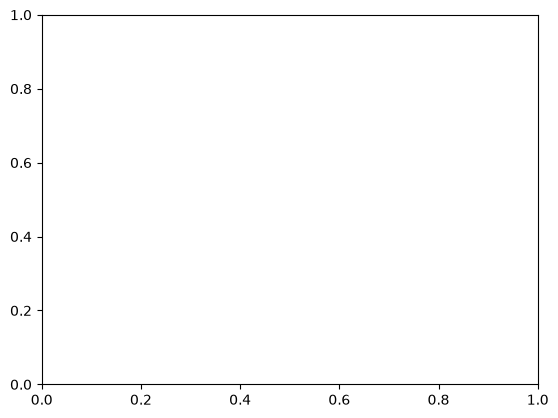

In [49]:
# i think this is supposed to be a plot of the speed of the glacier in m/yr
# why does it look different in the later plot and if i run it again later on?
# we get a different velocity from the solver later on so this is sort of like the initial velocity distribution
fig, axes = plt.subplots()
fd.plot(fd.Function(S).interpolate(u[0]), axes=axes);

In [ ]:
W = V * Σ * V * Q # cartesian product, velocity * stress * velocity * thickness

w = fd.Function(W)

# sub is short for subfunction and allows us to access components of a vector valued function
w.sub(0).assign(z.sub(0)) 
w.sub(1).assign(z.sub(1))
w.sub(2).assign(z.sub(2))
w.sub(3).assign(h);

In [ ]:
inflow_bc = fd.DirichletBC(W.sub(0), u_0, inflow_ids)
bcs = [inflow_bc]

u, M, τ, h = fd.split(w)
v, N, σ, η = fd.TestFunctions(W)

s = lag(max_value(b + h, (1 - ρ_I / ρ_W) * h))
fields = {
    "velocity": u,
    "thickness": h,
    "surface": s,
    "membrane_stress": M,
    "basal_stress": τ,
}

h_min = Constant(1e-3)
regularized = {"thickness": max_value(h_min, h)}

H = Constant(500.0)

In [ ]:
F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**fields)
F_terminus = terminus(**fields, terminus_ids=terminus_ids)

F_momentum = F_flow_law + F_sliding_law + F_balance + F_terminus

In [ ]:
F_flow_law_1 = flow_law(**(fields | {"thickness": H}), **parameters_1)
F_flow_law_3 = flow_law(**(fields | {"thickness": H}), **parameters_3)
F_flow_law = (1 / (1 + α) * F_flow_law_3 + α / (1 + α) * F_flow_law_1)

F_sliding_law_1 = friction_law(**(fields | regularized), **parameters_1)
F_sliding_law_3 = friction_law(**(fields | regularized), **parameters_3)
F_sliding_law = (1 / (1 + α) * F_sliding_law_3 + α / (1 + α) * F_sliding_law_1)

F_balance = momentum_balance(**(fields | regularized))
F_terminus = terminus(**(fields | regularized), terminus_ids=terminus_ids)

F_momentum_regularized = F_flow_law + F_sliding_law + F_balance + F_terminus

In [ ]:
a_0 = Constant(1.0)
m_0 = Constant(1.125)
z_b = s - h
heaviside = lambda z: 1 / (1 + fd.exp(-z))
#a_expr = a_0 - m_0 * heaviside(-z_b) * heaviside(z_b - b)
a_expr = a_0 - m_0 * heaviside(z_b - b)

In [ ]:
F_mass = mass_balance(
    thickness=h, velocity=u, accumulation=lag(a_expr), thickness_in=h_0
)
F = F_momentum + F_mass
Fp = F_momentum_regularized + F_mass

## Initial Deterministic Time Stepping

In [50]:
"""
Main driver:
"""

method = irksome.BackwardEuler()
t = Constant(0.0)
timestep = 0.2
dt = Constant(timestep)

fparams = {"quadrature_degree": 8}
sparams = {
    "snes_monitor": ":mismip-dual-ts.log",
    "snes_type": "vinewtonrsls",
    "snes_linesearch_type": "bt", 
    "snes_linesearch_max_it": 40,
    "snes_atol": 2e-8,
    "pc_factor_mat_solver_type": "superlu",
}
lower = fd.Function(W)
upper = fd.Function(W)
lower.assign(-np.inf)
lower.sub(3).assign(0.0)
upper.assign(+np.inf)

params = {
    "bcs": bcs,
    "form_compiler_parameters": fparams,
    "solver_parameters": sparams,
    "stage_type": "value",
    "basis_type": "Bernstein",
    "bounds": ("stage", lower, upper)
}

# updates w
solver = irksome.TimeStepper(F, method, t, dt, w, **params, Jp=Fp) # we want to solve the mass and momentum balance equation using backward euler
# the initial state is w
# boundary conditions are included in params

NameError: name 'W' is not defined

In [ ]:
USE_CACHE = True

final_time = 3000.0
num_steps = int(final_time / timestep)

# load_steady_state re-assigns mesh and w
if not USE_CACHE:
    # ws = [w.copy(deepcopy=True)]
    for step in trange(num_steps):
        solver.advance()
        # ws.append(w.copy(deepcopy=True))
else:
    match load_steady_state(mesh):
        case (mesh, w):
            print("restoring mesh and w from cache")
            # mesh = mesh
            w = w
        case _:
            for step in trange(num_steps):
                solver.advance()
            store_steady_state(mesh, w)

NameError: name 'mesh' is not defined

In [ ]:
u, M, τ, h = w.subfunctions # w is a field consisting of velocity, membrane stress, basal stress, thickness

In [ ]:
s = fd.Function(Q).interpolate(max_value(b + h, (1 - ρ_I / ρ_W) * h)) # surface of the glacier
z_b = fd.Function(Q).interpolate(s - h) # base of the glacier

NotImplementedError: Interpolating an expression with no arguments defined on multiple meshes is not implemented yet.

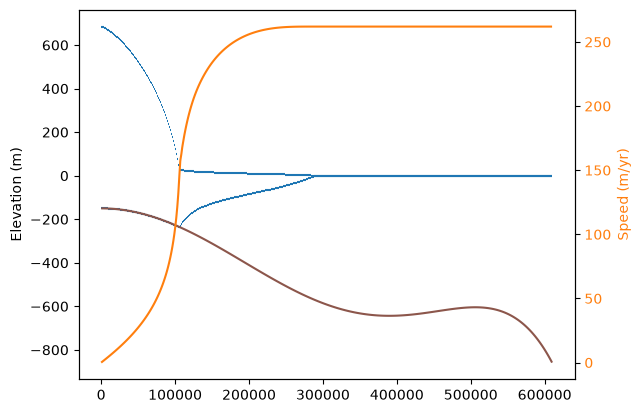

In [ ]:
fig, ax = plt.subplots()
ax.set_ylabel("Elevation (m)")
fd.plot(s, edgecolor="tab:blue", axes=ax)
fd.plot(z_b, edgecolor="tab:blue", axes=ax)
fd.plot(b, edgecolor="tab:brown", axes=ax)

ax = ax.twinx()
ax.set_ylabel("Speed (m/yr)", color="tab:orange")
ax.tick_params(axis="y", labelcolor="tab:orange")
u_x = fd.Function(S).interpolate(u[0])
fd.plot(u_x, edgecolor="tab:orange", axes=ax);

In [ ]:
# τ_b = fd.Function(Q).project(τ[0]) # basal stress ?
# fig, ax = plt.subplots()
# fd.plot(τ_b, axes=ax);

In [ ]:
# fig, ax = plt.subplots()
# a_expr = a_0 - m_0 * heaviside(z_b - b)
# a = fd.Function(Q).project(a_expr)
# fd.plot(a, axes=ax);

In [ ]:
# fig, ax = plt.subplots()
# mem_stress, _ = as_scalar(M)
# fd.plot(fd.Function(Q).interpolate(mem_stress), ax)

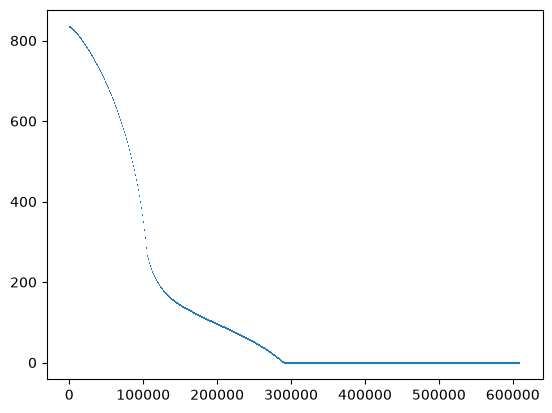

In [ ]:
"""plot of the thickness in steady state"""
fig, axes = plt.subplots()
fd.plot(fd.Function(Q).interpolate(w[3]), axes=axes);

## Introducing Stochastic Calving 

### Determining the Terminus

For calving events we need to know where the terminus is to be able to determine where the new terminus should be after the calving has occurred. 
In most cases, and assumed in my approach so far, the terminus is just the first point where the thickness function is zero. 
1. The first function I have defined finds this spot by creating a vertex only mesh for each integer value along the flow line (so for every meter) and then using np.where() to find the first value where it is zero. This is numerically quite expensive. 
A bit of a speed-up is achieved by making the spacing of the mesh larger, though for this to work one needs to multiply the result by the spacing that was used (since np.where returns the value's spot in the list of not its coordinates).
2. Another option is to access the values of the function at the nodes of the mesh using '.dat.data_ro'. This is an attribute of the function and is therefore quite fast.
The problem with this approach is that there are only 450 intervals, so the step sizes are about 1335 which means the actual terminus position can be up to 1.3 km further to the left.
3. The next option would be to combine these two approaches. This would mean first finding the interval in which the terminus lies and then using creating a finer vertex only mesh on that interval to find the exact position.

In [ ]:
def end_of_glacier(f):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_init_values = f.dat.data_ro # faster but less data point way to access the values of f
    if f_init_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    f_mesh = fd.Function(f).ufl_domain()
    points = np.arange(0, 610_000, 10)[:, None] # list of lists (requirement for the vertex only mesh)
    vom = fd.VertexOnlyMesh(f_mesh, points)
    P = fd.FunctionSpace(vom, "DG", 0)
    f_at_points = fd.assemble(fd.interpolate(f, P)) 
    f_values = f_at_points.dat.data_ro

    # if f_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
    #     return 'empty'
    zeros = np.where(f_values==0)[0]

    return int(zeros[0])*10 # this gives us the first point at which the thickness is zero

In [ ]:
def end_of_glacier2(f):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_values = f.dat.data_ro # if hasattr(f, "dat") else fd.Function(f).dat.data_ro
    # print(f_values)
    zeros = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]
    # print(zeros)

    if len(zeros) == 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    return int(zeros[0]*(610_000/450)) # this gives us the first point at which the thickness is zero

In [ ]:
def end_of_glacier3(f):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_values = f.dat.data_ro # if hasattr(f, "dat") else fd.Function(f).dat.data_ro
    zero_nodes = np.where(np.isclose(f_values, 0.0, atol=1e-12))[0]

    if len(zero_nodes) == 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    initial_guess = zero_nodes[0] # this gives us the first node of our mesh at which the thickness is zero

    submesh = fd.mesh.Submesh(mesh, subdomain_id=initial_guess-1)

    points = np.arange(0, 1356, 1)[:, None]
    vom = fd.VertexOnlyMesh(submesh, points)
    P = fd.FunctionSpace(vom, "DG", 0)
    f_at_points = fd.assemble(fd.interpolate(f, P)) 
    f_values = f_at_points.dat.data_ro

    zeros = np.where(f_values==0)[0]
    return int(zeros[0])

In [ ]:
610_000/450

1355.5555555555557

In [ ]:
# this is one is actually slower than the original end_of_glacier
def end_of_glacier4(f):
    """
    This function takes a (thickness) function f on a 1-D mesh and returns the first integer where f is zero.
    """
    f_init_values = f.dat.data_ro # faster but less data point way to access the values of f
    if f_init_values[-1] != 0: # if the this is the case then the terminus lies outside of our domain
        return 'empty'
    f_mesh = fd.Function(f).ufl_domain()
    points = np.arange(0, 610_000, 10)[:, None] # list of lists (requirement for the vertex only mesh)

    point_evaluator = fd.function.PointEvaluator(mesh, points)

    f_at_points = point_evaluator.evaluate(f)

    zeros = np.where(f_at_points==0)[0]

    return int(zeros[0])*10 # this gives us the first point at which the thickness is zero

: 

In [ ]:
L1 = end_of_glacier3(fd.Function(Q).interpolate(w[3]))
print(L1)

: 

In [ ]:
print(end_of_glacier2(fd.Function(Q).interpolate(w[3])))

291444


In [ ]:
L3 = end_of_glacier3(fd.Function(Q).interpolate(w[3]))
print(L3)

NameError: name 'end_of_glacier3' is not defined

The (reverse) logistic function allows us to impose the new terminus smoothly.

In [ ]:
def logistic_function(y, new_term, k=10):
    """A variation on the logistic function that is 1 at -∞ and 0 at ∞ and continuously moves between the two centered at new_term. 
    The steepness of the transition is give by k."""
    # x = ufl.SpatialCoordinate(Q)
    return 1-1/(1+ufl.exp(-k*(y-new_term)))

In [ ]:
logistic_function(1, 1)

0.5

### Solver #2: exponential rate calving approach

This solver implements rate based calving. We assume that we have exponentially distributed calving events.
The size of the calving events is normally distributed.

In [ ]:
"""Calving with exponentially distributed occurrance and size"""

mean = 9_000
deviation = 4_000
beta = 5000
num_calv_events = 10

calving_spacing = np.random.exponential(beta, num_calv_events)
calve_time = calving_spacing.cumsum().round()
calve_size = np.random.normal(mean, deviation, num_calv_events).round()

# this next code ensures that we do 15_000 time steps 
calve_num = np.where(calve_time>= 15_000)[0]
if len(calve_num)==0:
    icebergs = calve_size
    calving_events = calve_time
else:
    icebergs = np.append(calve_size[:calve_num[0]], 0)
    calving_events = np.append(calve_time[:calve_num[0]], 15000)

In [ ]:
print(calve_size)
print(icebergs)

[12080.  9269.  2392.  4317.  9257.  8111. 14944. 12011.  4867.  9022.]
[12080.  9269.  2392.     0.]


In [ ]:
print(calve_time)
print(calving_events)

[ 2376.  4977. 11676. 17147. 22513. 27695. 31555. 65446. 73155. 73458.]
[ 2376.  4977. 11676. 15000.]


In [ ]:
# w2 = w

# solver2 = irksome.TimeStepper(F, method, t, dt, w2, **params, Jp=Fp)

# final_time = 3000
# num_steps = int(final_time / timestep)

# ws = [w2.copy(deepcopy=True)]
# terminus_pos = []

# step = 0
# for i, e in enumerate(calving_events):
#     while step < e:
#         print(step)
#         solver2.advance()
#         step += 1
#         ws.append(w2.copy(deepcopy=True))

#     print(step)
#     h = w2.sub(3)
#     f = fd.Function(Q)
#     term = end_of_glacier(h)
#     if term == 'empty':
#         solver2.advance()
#         step += 1
#         ws.append(w2.copy(deepcopy=True))
#     else:
#         new_term = int(term - icebergs[i])
#         terminus_pos += [(term, new_term)]
#         print((term, new_term))
#         x = fd.SpatialCoordinate(fd.Function(h).ufl_domain())
#         # expr = fd.conditional(fd.le(x, new_term), h, 0.0)
#         # h_at_x = h.at(x)[0]
#         # expr = h * fd.conditional(fd.le(x[0], new_term), 1, 0)
#         expr = h * logistic_function(x[0], new_term)
#         f.interpolate(expr)
#         w2.sub(3).assign(f)

#         solver2.advance()
#         step += 1
#         ws.append(w2.copy(deepcopy=True))

### Solver #3: position based calving approach
This solver is supposed to incorporate calving that is dependent on the position of the terminus of the glacier. 
This is numerically quite bad because for each(!) time step the terminus has to be calculated, which is numerically very expensive.
Based on the terminus position the probability that a calving event will occur is then calculated.
This means that we have a process of Bernoulli trials that are neither independent nor identically distributed (very crazy and bad).
This in turn means that the waiting times between events are not exponentially distributed (might be bad).

For the calving size I have two ideas/options:
1. Current implementation: The new terminus is determined based on the current position (approximately normally distributed behind the current position). 
This is not working not so well at the moment.
It can lead to very large calving events if the terminus is very far along the flow line (for this reason this method only works from a steady state).
Another problem with this approach is that it can technically lead to the theoretical terminus being farther in front.
In practice the implementation prevents this from happening, but it still skews the distribution 
(as in: it becomes less likely for a calving event to occur than one would assume based on the probabilities for the Bernoulli trial).
2. The calving size is independent of the terminus position. So we have a normal distribution centered around expected iceberg size.
This might actually the better approach at the moment.

In [ ]:
def calving_prob(term_pos):
    """takes the terminus position as an argument and returns whether or not a calving event occurrs at this time step"""
    p = sp.stats.norm(400_000, 10_000).cdf(term_pos) # for each point the probabilty of a calving event is the cdf of the normal distribution at that point
    return int(np.random.binomial(1, p, 1)[0])

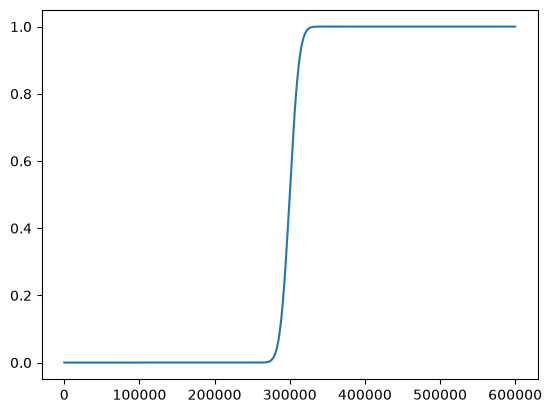

In [ ]:
# this plot is there to help visualize the probability of the calving event occuring at each spot along the flow line
# at the moment there is no specific reason why I chose the cdf of the normal distribution other than that it fits the shape I want and is easily adjustable
# the connection to a probability distribution could be misleading because I could really choose any function with image [0,1]
fig, ax = plt.subplots()
x = np.linspace(0,600_000, 600_000)
ax.plot(x, sp.stats.norm(300_000, 10_000).cdf(x));

In [ ]:
# # old version
# def new_terminus(term_pos):
#     bernoulli_trial = calving_prob(term_pos)
#     if bernoulli_trial == 0:
#         return term_pos
#     if bernoulli_trial == 1:
#         return int(np.random.normal((term_pos+100_000)//2, (term_pos+100_000)//4, 1)[0])

In [ ]:
# problem: leads to large jumps toward the middle
def new_terminus(term_pos):
    """this function determines the new terminus position based on the current position"""
    return int(np.random.normal((term_pos+500_000)//2, (term_pos+200_000)//16, 1)[0])

In [ ]:
def calve_size():
    return int(np.random.normal(20_000, 10_000))

In [ ]:
calve_size()

20190

In [ ]:
# fig, ax = plt.subplots()
# x = np.linspace(0, 600_000, 600_000)
# y_list = np.linspace(0, 600_000, 10).round()
# for y in y_list:
#     ax.plot(x, sp.stats.norm((y+200_000)//2, 20_000).pdf(x), label=f'y={y}')
#     ax.legend();

In [ ]:
new_terminus(L1)

376977

In [ ]:
w3 = w

# params_3 = params.pop("stage_type")
# scheme = irksome.DiscontinuousGalerkinScheme(1)
# solver3 = irksome.discontinuous_galerkin_stepper.DiscontinuousGalerkinTimeStepper(F, scheme, t, dt, w3, **params, Jp=Fp)

solver3 = irksome.TimeStepper(F, method, t, dt, w3, **params, Jp=Fp)

ws = [w3.copy(deepcopy=True)]
calve_term_change_list= []
term_position = []


for n in trange(num_steps):
    h = w3.sub(3) # thickness
    f = fd.Function(Q)
    # g = fd.Function(Q)
    term = end_of_glacier2(h) # determine terminus
    term_position += [term]
    if term == 'empty': # if the terminus is outside the domain, no calving
        solver3.advance()
        ws.append(w3.copy(deepcopy=True))
    else:
        p = calving_prob(term)
        if p == 0: # no calving
            solver3.advance()
            ws.append(w3.copy(deepcopy=True))
        # # Position based calving size
        # else:
        #     new_term = new_terminus(term) # determine new terminus
        #     calve_term_change_list += [(term, new_term)]
        #     # print((term, new_term))

        #     x = fd.SpatialCoordinate(fd.Function(h).ufl_domain())
        #     # this imposes the new terminus by defining a new function that is 0 up flow of the new terminus (also does not allow for "forward calving")
        #     expr = h * fd.conditional(fd.le(x[0], new_term), 1, 0)  
        #     f.interpolate(expr)
        #     w3.sub(3).assign(f)

        #     solver3.advance()
        #     ws.append(w3.copy(deepcopy=True))
        # Rate based calving size
        else:
            new_term = term-calve_size() # determine new terminus
            calve_term_change_list += [(term, new_term)]
            # print((term, new_term))

            x = fd.SpatialCoordinate(fd.Function(h).ufl_domain())
            # this imposes the new terminus by defining a new function that is 0 up flow of the new terminus (also does not allow for "forward calving")
            # expr = h * fd.conditional(fd.le(x[0], new_term), 1, 0)
            # expr_1 = logistic_function(x, new_term)
            # g.interpolate(expr_1)
            expr = h * (1 - 1/(1+ufl.exp(-10*(x[0]-new_term))))
            f.interpolate(expr)
            w3.sub(3).assign(f)

            solver3.advance()
            ws.append(w3.copy(deepcopy=True))

  0%|          | 0/15000 [00:00<?, ?it/s]

ConvergenceError: Nonlinear solve failed to converge after 50 nonlinear iterations.
Reason:
   DIVERGED_MAX_IT

### Analyzing and Plotting the Results

In [ ]:
print(terminus_pos)

NameError: name 'terminus_pos' is not defined

In [ ]:
print(calve_term_change_list)

print(term_position)

[(364644, 347782)]
[291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 291444, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 292800, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 294155, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 295511, 2955

In [ ]:
def terminus_development(term_list):
    """This function takes a list of values and then creates an x-axis that enumerates the points. In this context this is useful for plottting a 
    quantity that we are trackin over time (so for each time step)."""
    n = len(term_list)
    x_list = np.arange(n)
    fig, ax = plt.subplots()
    # ax.set_ylim(100_000, 600_000)
    return ax.plot(x_list, term_list)

[261, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 262, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 263, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 264, 255, 255, 255, 256, 256, 256, 257, 257, 257, 257, 258, 258, 258, 258, 259, 259, 259, 259, 259, 260, 260, 260, 260, 260, 260, 260, 261, 261, 261, 261, 261, 261, 261, 261, 262, 262, 262, 218, 219, 220, 200, 201, 196, 194, 194, 195, 195, 195, 196, 196, 196, 197, 197, 197, 198, 198, 198, 199, 199, 200, 200, 201, 201, 202, 202, 203, 203, 204, 205, 205, 206, 206, 207, 207, 208, 209, 209, 210, 210, 211, 212, 212, 213, 213, 214, 215, 215, 216, 216, 217, 217, 218, 219, 219, 220, 220, 221, 221, 221, 222, 222, 223, 223, 224, 224, 225, 225, 225, 226, 226, 226, 227, 227, 227, 228, 228, 228, 229, 229, 229, 230, 230, 230, 230, 231, 231, 231, 232, 232, 232, 232, 233,

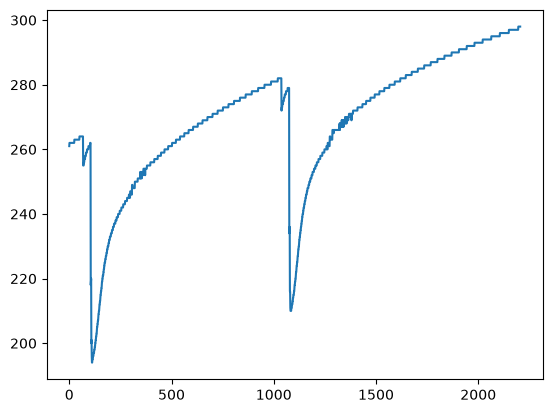

In [ ]:
# this plot shows the velocity at approximatley the terminus of the glacier
# it seems that the velocity changes quite a bit and quite rapidly (I don't understand the physics of this)

terminus_velocities = []
for w in ws:
    u = w.sub(0)
    u_at_points = u.dat.data_ro
    terminus_velocities += [int(u_at_points[-1])]

print(terminus_velocities)

terminus_development(terminus_velocities)

In [ ]:
# this figure shows the developement over time of the velocity of the glacier along the flowline
# in the case without calving the velocity toward the end of the flowline varies quite a bit (spanning from ~175 to ~340)

# fig, ax = plt.subplots()
# for w in ws:
#     u = w.sub(0)
#     u_x = fd.Function(S).interpolate(u[0])
#     fd.plot(u_x, axes=ax);

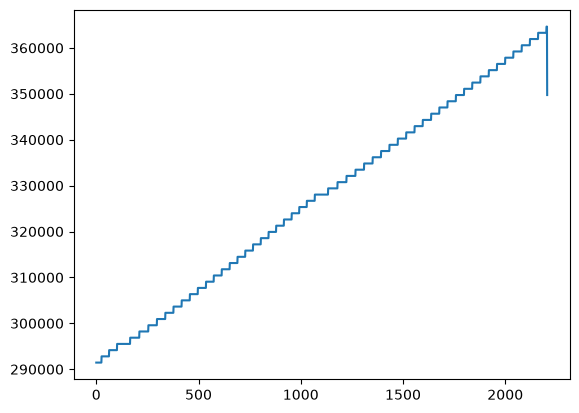

In [ ]:
# this plot shows the position of the terminus over time
terminus_development(term_position)

In [ ]:
u, M, τ, h = w.subfunctions # w is a field consisting of velocity, membrane stress, basal stress, thickness

In [ ]:
s = fd.Function(Q).interpolate(max_value(b + h, (1 - ρ_I / ρ_W) * h)) # surface of the glacier
z_b = fd.Function(Q).interpolate(s - h) # base of the glacier

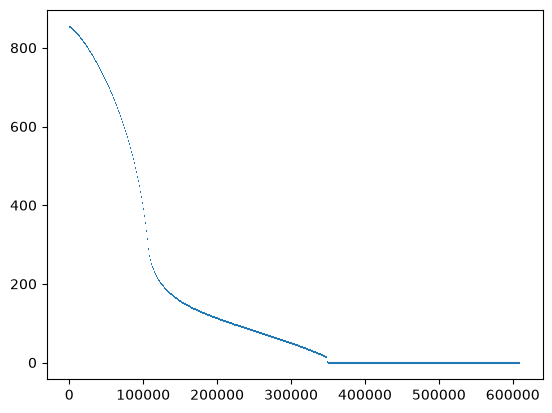

In [ ]:
# a plot of the thickness function
fig, axes = plt.subplots()
fd.plot(h, axes=axes);

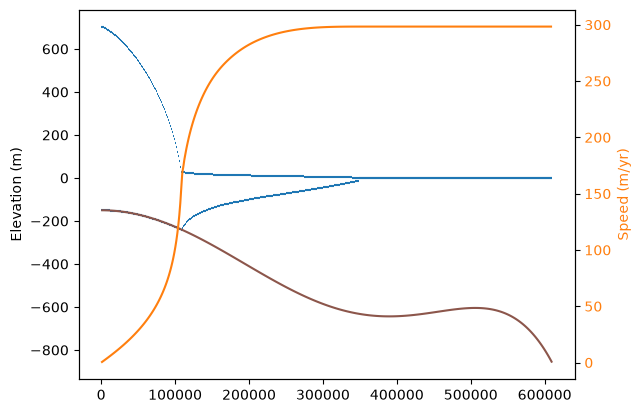

In [ ]:
fig, ax = plt.subplots()
ax.set_ylabel("Elevation (m)")
fd.plot(s, edgecolor="tab:blue", axes=ax)
fd.plot(z_b, edgecolor="tab:blue", axes=ax)
fd.plot(b, edgecolor="tab:brown", axes=ax)

ax = ax.twinx()
ax.set_ylabel("Speed (m/yr)", color="tab:orange")
ax.tick_params(axis="y", labelcolor="tab:orange")
u_x = fd.Function(S).interpolate(u[0])
fd.plot(u_x, edgecolor="tab:orange", axes=ax);

In [ ]:
print(end_of_glacier(w.sub(3)))

417520


In [ ]:
ice_surface = []
ice_base = []
for k in ws:
    u1, M1, τ1, h1 = k.subfunctions
    s1 = fd.Function(Q).interpolate(max_value(b + h1, (1 - ρ_I / ρ_W) * h1))
    z_b_1 = fd.Function(Q).interpolate(s1 - h1)
    ice_surface += [s1]
    ice_base += [z_b_1]

KeyboardInterrupt: 

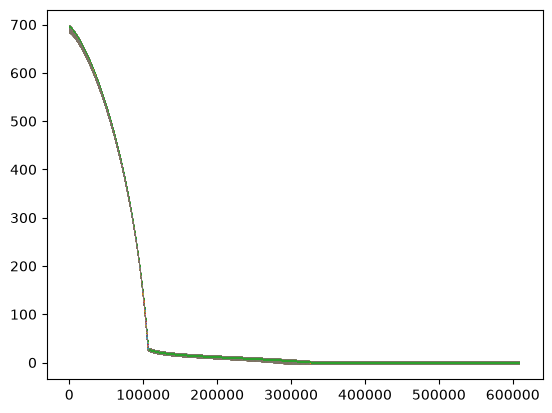

In [ ]:
# a plot of the surface over time (not overly useful because you can't really see much)
fig, ax = plt.subplots()
for surface in ice_surface:
    fd.plot(surface, axes=ax);

### Calving video
Here I will try to turn the calving development into a video at some point (aka when things are working).

NotImplementedError: Cannot take length of non-vector expression.

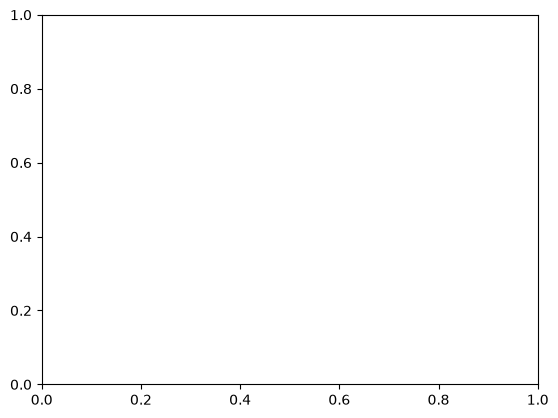

In [ ]:
fig, axes = plt.subplots()
colors = plt.plot(
    ws[0], num_sample_points=4, vmin=0.0, vmax=1.0, cmap='inferno'
)

In [ ]:
fn_plotter = fd.FunctionPlotter(mesh, num_sample_points=4)
def animate(T):
    colors.set_array(fn_plotter(T))

animation = FuncAnimation(fig, animate, frames=tqdm(ws), interval=1e3 / 24)

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
HTML(animation.to_html5_video())

NameError: name 'colors' is not defined